# Which water mains to replace: Gaussian processes and decision theory

A Gaussian process returns a full predictive distribution, not a point estimate. Decision theory (Rasmussen and Williams, chapter 2) turns that distribution into the action that minimizes expected loss. This notebook shows the pair working on a real problem: predicting water main break rates across the City of Kitchener from its open break records, then deciding, in dollars, which pipes to replace and how large an emergency budget to hold.

The models are built with [ptgp](https://github.com/wrengels/ptgp) the way real modeling goes: start with a plain GP, check where it falls short, and escalate. Three models, one clear step at a time:

1. **Model 1**: a sparse variational GP (SVGP) over pipe age, size, location, material, and pressure zone, with a Poisson likelihood and an exposure offset.
2. **Model 2**: + each pipe's prior break rate and the calendar year as single linear coefficients in the mean, under an **R2D2 prior** that budgets the model's explained variance across its components.
3. **Model 3**: the best GP the R2D2M2 family supports, with a per-pipe *frailty* joining the budget.

Every model is validated as it would be used: an annual planning cycle replayed over 2019-2025 and scored against the breaks that actually happened. A tuned gradient-boosting benchmark and a classical Poisson GLM set the bar the final model must clear.

Mechanical code (data fetching, cross-validation, plotting) lives in the companion module [`watermains.py`](watermains.py) and stays out of view; the code shown is the ptgp modeling itself. Deeper methods live in the [supplement](watermains_supplement.ipynb).

## The data

The City of Kitchener, Ontario publishes its entire drinking-water network as [open data](https://open-kitchenergis.opendata.arcgis.com/): about 16,000 active water mains spanning 934 km, and roughly 3,000 breaks recorded since 1995. (The break layer nominally extends back to 1985, but its first decade holds just eight records, so effective coverage starts in 1995; every window in this notebook respects that.) Every main carries its installation year, material, diameter, length, and pressure zone; every break carries a date, a location, and the main it happened on. Materials run from modern PVC and ductile iron to the brittle cast iron laid a century ago, and it is that old cast iron, not the most common pipe in the ground, that accounts for most of the breaks. The notebook pulls both layers live from the city's ArcGIS service, so everything below is reproducible from source.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import ptgp as pg

import watermains as wm

breaks, mains, mains_geoms = wm.load_kitchener_data(cache_path="watermains_cache.pkl")
_, mb, _ = wm.build_modeling_frame(mains, breaks)
base = wm.static_frame(mains)
segs = wm.line_segments(mains_geoms)
print(
    f"{len(base)} active mains, {int(wm.break_table(base, breaks).to_numpy().sum())} linked main breaks"
)

16133 active mains, 2415 linked main breaks


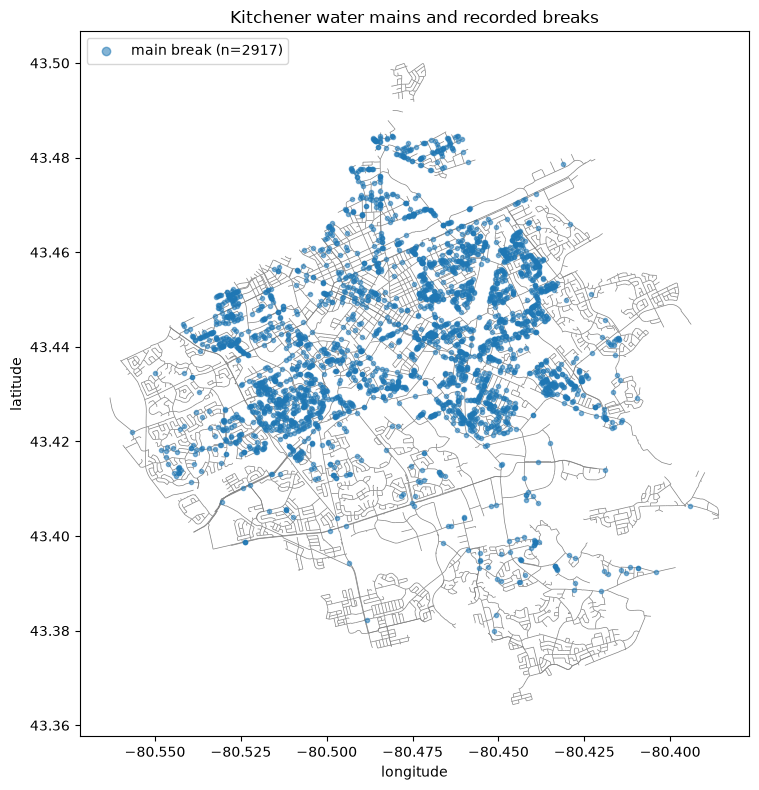

In [2]:
wm.plot_network(segs, mb)

## What the model sees

Each pipe contributes: **age**, **diameter** (log mm), **location** (segment centroid), **material** and **pressure zone** (integer-coded into rank-2 `LowRankCategorical` kernels that learn a covariance between levels instead of assuming them independent), and **exposure** (pipe-km-years, a fixed log offset so the model predicts a rate). Model 2 adds **calendar year** and each pipe's **prior break rate**. How the categorical levels were consolidated, and why each feature earns its place, is in the [supplement](watermains_supplement.ipynb).

## The data as a planner sees it: pipe-years, replayed annually

A utility plans annually: standing at the start of year $t$ it knows everything before $t$, predicts the coming year, sets an emergency budget, and picks mains to replace. The data are arranged the same way, one row per pipe per year from 1995 on: the target is that pipe's breaks in that year, exposure is one year of its length, and covariates (age, and later the history feature) are measured at that year. Over half of today's network (518 of 934 km) predates 1995, so the panel is well populated from its first year, and pipe-year rows cost an SVGP nothing extra, since training is minibatched either way.

The evaluation replays the planning cycle: for each year $t$ from 2019 through 2025 (2026 is only half recorded), every model trains on all rows before $t$, roughly 340,000 by the last fold, and predicts the year-$t$ slice, which it has never seen. The history feature is each pipe's empirical break rate over `[1995, s)`, strictly before its row's year $s$, so nothing circular enters. Fits are cached to disk, so re-running the notebook is cheap.

The code shown below trains each model once on the full record through 2025, the fit a planner would deploy for 2026; the identical construction runs inside the cross-validation.

In [3]:
FOLDS = list(range(2019, 2026))
folds = {t: wm.build_panel(mains, breaks, float(t)) for t in FOLDS}

# the deployment dataset: every complete year, plus the 2026 slice to predict
train_all, plan26 = wm.build_panel(mains, breaks, 2026.0)
X, stats = wm.panel_design(train_all)
X26, _ = wm.panel_design(plan26, stats)
y = train_all["y"].to_numpy(float)

pd.DataFrame(
    {
        t: {
            "train rows": len(tr),
            "train breaks": int(tr["y"].sum()),
            "test breaks": int(te["y"].sum()),
        }
        for t, (tr, te) in folds.items()
    }
).T

,train rows,train breaks,test breaks
2019,232363,1559,74
2020,246328,1633,61
2021,261126,1694,75
2022,276315,1769,90
2023,291792,1859,43
2024,307524,1902,53
2025,323424,1955,78


## Choosing the inducing points

With 16,000 pipes and 400,000 pipe-year rows, exact GP inference is out of reach; a sparse variational GP summarizes the data through M inducing points, and where those points sit controls how well the sparse posterior matches the exact one. A random subsample over-picks the many near-identical PVC rows and under-represents the rare pipes that drive the model. ptgp ships `greedy_variance_init` (Burt et al. 2020): a pivoted Cholesky of the kernel matrix that adds, at each step, the point with the largest conditional variance given the points already chosen, covering the input space by prior variance rather than by density.

```python
Z0, vp, diag = wm.init_inducing(X, M=1024)   # wraps pg.inducing.greedy_variance_init
```

The selection curve below runs past the chosen size, to M = 2048, under a deliberately conservative proxy (unit lengthscales on Model 1's four continuous dimensions): the unexplained fraction of prior variance halves roughly every doubling of M, and **M = 1024** leaves only a few percent even on this worst-case view. The proxy overstates what the model actually needs: fitted ARD lengthscales come out far longer than 1 on most dimensions (location and diameter are nearly flat), collapsing the effective dimensionality to about two, under which the residual at M = 1024 is a fraction of a percent. Two details worth knowing:

- **The inducing locations are then trained**, jointly with the hyperparameters and variational parameters, inside the SVGP optimization loop. The greedy set is a strong start, not a commitment.
- **The integer code columns take care of themselves.** The material and zone columns of Z start at valid category codes because greedy selection picks real data rows, and during training they receive exactly zero gradient: the `LowRankCategorical` kernel casts its column to integer, and the gradient of an integer cast is zero. Only the continuous columns move.

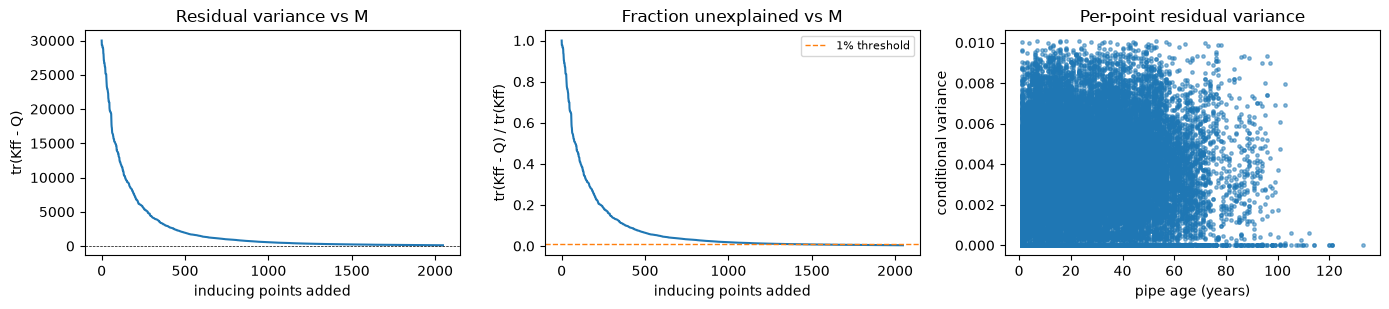

M = 2048: 99.6% of prior variance explained; worst-covered point d = 0.010


In [4]:
Zsel, vpsel, ip_diag = wm.init_inducing(X, M=2048)  # curve computed past the chosen M
d_final, sub_idx = wm.inducing_diagnostics(X, Zsel)
wm.plot_inducing_diagnostics(ip_diag, d_final, train_all["age"].to_numpy()[sub_idx])

## Model 1: a sparse variational GP

Each pipe-year count is Poisson with a latent log-rate that is a GP over the covariates. In ptgp the model is a kernel expression plus a likelihood, wrapped in a PyMC model so the hyperparameters get priors: a Matern 5/2 with ARD over the continuous dims, times a rank-2 `LowRankCategorical` for material, times another for pressure zone. The exposure offset rides in a small mean function so it travels with each minibatch.

One identifiability detail is worth fixing up front. In a product kernel only the *product* of the factor scales is identified: the amplitude $\eta$ can shrink while the categorical diagonals grow with no change to the model. The categorical kernels below are therefore normalized so that their frequency-weighted mean diagonal is 1 (`wm.NormalizedLowRankCategorical`, a ten-line subclass in the companion module): relative per-level variances are untouched, and $\eta^2$ becomes the model's mean per-point prior variance, a single well-defined quantity that Model 2's variance budget will need. This is the entire model and its training loop:

In [5]:
n_mat, n_zone = int(X[:, wm.MAT_COL].max()) + 1, int(X[:, wm.ZONE_COL].max()) + 1
freq_mat = np.bincount(X[:, wm.MAT_COL].astype(int), minlength=n_mat) / len(X)
freq_zone = np.bincount(X[:, wm.ZONE_COL].astype(int), minlength=n_zone) / len(X)
Z1, vp1, _ = wm.init_inducing(X, M=1024)

with pm.Model() as model1:
    c = pm.Normal("c", mu=np.log(y.sum() / np.exp(X[:, wm.EXPO_COL]).sum()), sigma=1.0)
    ls = pm.InverseGamma("ls", alpha=3.0, beta=3.0, shape=4)
    eta = pm.HalfNormal("eta", sigma=1.5)
    k_cont = eta**2 * pg.kernels.Matern52(input_dim=10, ls=ls, active_dims=[0, 1, 2, 3])

    W_mat = pm.Normal(
        "W_mat",
        0.0,
        1.0,
        shape=(n_mat, 2),
        initval=0.1 * np.random.default_rng(0).standard_normal((n_mat, 2)),
    )
    kappa_mat = pm.HalfNormal("kappa_mat", sigma=1.0, shape=n_mat)
    k_mat = wm.NormalizedLowRankCategorical(
        input_dim=10,
        num_levels=n_mat,
        W=W_mat,
        kappa=kappa_mat,
        freqs=freq_mat,
        active_dims=[wm.MAT_COL],
    )

    W_zone = pm.Normal(
        "W_zone",
        0.0,
        1.0,
        shape=(n_zone, 2),
        initval=0.1 * np.random.default_rng(1).standard_normal((n_zone, 2)),
    )
    kappa_zone = pm.HalfNormal("kappa_zone", sigma=1.0, shape=n_zone)
    k_zone = wm.NormalizedLowRankCategorical(
        input_dim=10,
        num_levels=n_zone,
        W=W_zone,
        kappa=kappa_zone,
        freqs=freq_zone,
        active_dims=[wm.ZONE_COL],
    )

    Z_var = pt.matrix("Z")  # trainable inducing points, initialized at the greedy set
    svgp1 = pg.gp.SVGP(
        kernel=k_cont * k_mat * k_zone,
        likelihood=pg.likelihoods.Poisson(),
        mean=wm.ExposureOffset(c, col=wm.EXPO_COL),
        inducing_variable=pg.inducing.Points(Z_var, Z_init=Z1),
        variational_params=vp1,
    )

Xv, yv = pt.matrix("X"), pt.vector("y")
step, shared, extras = pg.optim.compile_training_step(
    lambda gp, Xb, yb: pg.objectives.elbo(gp, Xb, yb, n_data=len(y)).elbo,
    svgp1,
    Xv,
    yv,
    model=model1,
    extra_vars=[*vp1.extra_vars, Z_var],
    extra_init=[*vp1.extra_init, Z1],
    learning_rate=1e-2,
)

rng = np.random.default_rng(0)
for i in range(700):
    sel = rng.choice(len(y), 1024, replace=False)
    loss = step(X[sel], y[sel])
    if i % 100 == 0 or i == 699:
        print(f"step {i:4d}  loss {loss:,.0f}")

step    0  loss 8,226


step  100  loss 8,435


step  200  loss 10,564


step  300  loss 4,436


step  400  loss 12,829


step  500  loss 9,743


step  600  loss 6,295


step  699  loss 9,386


In [6]:
import pickle
from pathlib import Path


def run_model(key, fit_fn):
    """Fit one model on every fold, cached to disk; returns the fold cache dict."""
    out = {}
    for t, (train, test) in folds.items():
        cache = Path(f"watermains_cv_seq97_{t}.pkl")
        fold = pickle.loads(cache.read_bytes()) if cache.exists() else {}
        if "n_test" not in fold:
            fold.update(
                n_test=test["y"].to_numpy(float),
                expo_test=test["length_km"].to_numpy(float),
                diam=test["diam"].to_numpy(float),
                length_km=test["length_km"].to_numpy(float),
            )
        if key not in fold:
            fold[key] = fit_fn(train, test, t)
            cache.write_bytes(pickle.dumps(fold))
            print(f"[{t}] {key} fit")
        out[t] = fold
    return out


cv = run_model(
    "m1",
    lambda train, test, t: dict(
        zip(("fm", "fv"), wm.fit_panel_gp(train, test, M=1024, n_steps=700, eval_size=32768))
    ),
)

The same construction, refit inside the walk-forward replay, gives Model 1's scorecard. Every model in this notebook is scored on the same seven held-out years, with these columns:

- **ELPD** (expected log predictive density): the summed log-probability each model assigns to the breaks that actually happened, the standard score for probabilistic forecasts. Higher (less negative) is better; it rewards getting both the rate *and* the uncertainty right. GP models integrate over their posterior via draws; point-prediction benchmarks get a plug-in score, flagged as such.
- **ROC-AUC**: the probability that a randomly chosen pipe that broke next year is ranked above one that did not. 0.5 is coin-flipping; 1.0 is perfect ordering.
- **AUC-PR**: area under the precision-recall curve, the ranking score that matters when positives are rare (about 0.3% of pipe-years break). The baseline for a random ranker is the positive rate itself.
- **captured @ $5M/yr**: a budgeted field test of the ranking. Each planning year, replace pipes in the model's order until $5M of replacement capital is spent; count how many of that year's actual breaks the plan would have pre-empted, summed over 2019-2025.
- **calibration z²**: the mean of $(y - \mathbb{E}[N])^2 / \mathrm{Var}[N]$ over test pipe-years. 1.0 means the predictive variances are sized exactly right; above 1 means overconfidence (variances too small), below 1 underconfidence.

In [7]:
def model_row(key):
    """Pooled walk-forward scores for one model."""
    y_pool, p_pool, z2, elpd, captured = [], [], [], 0.0, 0.0
    for t in FOLDS:
        fold = cv[t]
        expo, n_test = fold["expo_test"], fold["n_test"]
        d = fold[key]
        if "fm" in d:
            EN, VN = wm.poisson_moments(d["fm"], d["fv"], expo)
            prob = wm.rate_to_prob(wm.latent_to_rate(d["fm"], d["fv"]), expo)
            elpd += wm.elpd_poisson(n_test, wm.latent_draws(d["fm"], d["fv"], 500, seed=0), expo)
        else:  # rate-only benchmark: plug-in Poisson, no parameter uncertainty
            rate = np.clip(d["rate"], 1e-9, None)
            EN = VN = rate * expo
            prob = wm.rate_to_prob(rate, expo)
            elpd += wm.elpd_poisson(n_test, np.log(rate)[None, :], expo)
        y_pool.append((n_test > 0).astype(int))
        p_pool.append(prob)
        z2.append((n_test - EN) ** 2 / VN)
        rc = wm.replacement_cost(fold["diam"], fold["length_km"])
        captured += wm.dollar_backtest({key: EN}, rc, n_test, budget=5.0)[key][2]
    pooled = wm.evalm(np.concatenate(y_pool), np.concatenate(p_pool))
    return {
        "ELPD": round(elpd, 1),
        "ROC-AUC": round(pooled["ROC_AUC"], 3),
        "AUC-PR": round(pooled["AP"], 3),
        "captured @ $5M/yr": round(captured, 1),
        "calibration z^2": round(float(np.concatenate(z2).mean()), 2),
    }


LABELS = {
    "m1": "Model 1",
    "m2": "Model 2 (+history, +year means; R2D2)",
    "m3": "Model 3",
    "hgb": "HGB (tuned, plug-in)",
    "glm": "Poisson GLM (plug-in)",
}
results = {}


def show_table(*keys):
    """Add rows for the given models and show the running comparison table."""
    for k in keys:
        results[LABELS[k]] = model_row(k)
    return pd.DataFrame(results).T


show_table("m1")

,ELPD,ROC-AUC,AUC-PR,captured @ $5M/yr,calibration z^2
Model 1,-2310.1,0.925,0.053,49.0,0.86


## Model criticism: what is Model 1 missing?

Two checks say the covariates are not the whole story. Pipes that have already broken keep breaking at several times the rate of comparable pipes that never did: break history carries signal (persistent unobserved condition: bedding, water hammer, past repair quality) that age, material, zone, and location miss. And the model has no notion of calendar time, so it cannot express the fact that the network as a whole breaks less than it used to. (The overdispersion view of the same facts is in the [supplement](watermains_supplement.ipynb).)

In [8]:
mby = wm.attach_break_year(mb)
broke_pre = base["WATMAINID"].isin(set(mby.loc[mby["break_year"] < 2010, "ASSETID"])).to_numpy()
n_post = (
    base["WATMAINID"]
    .map(mby.loc[mby["break_year"] >= 2010, "ASSETID"].value_counts())
    .fillna(0)
    .to_numpy(float)
)
expo_post = base["length_km"].to_numpy(float) * (wm.AS_OF - 2010.0)
r_prev = n_post[broke_pre].sum() / expo_post[broke_pre].sum()
r_never = n_post[~broke_pre].sum() / expo_post[~broke_pre].sum()
print(
    f"2010-2026 break rate: broke before 2010 = {r_prev:.3f}/km-yr vs never = {r_never:.3f}/km-yr "
    f"({r_prev / r_never:.1f}x)"
)

pred_tot = [
    wm.poisson_moments(cv[t]["m1"]["fm"], cv[t]["m1"]["fv"], cv[t]["expo_test"])[0].sum()
    for t in FOLDS
]
real_tot = [cv[t]["n_test"].sum() for t in FOLDS]
print(
    f"annual totals, Model 1 vs realized: predicted {np.mean(pred_tot):.0f}/yr on average, "
    f"realized {np.mean(real_tot):.0f}/yr; over-forecast in {int(np.sum(np.array(pred_tot) > np.array(real_tot)))} of 7 years"
)

2010-2026 break rate: broke before 2010 = 0.347/km-yr vs never = 0.051/km-yr (6.8x)
annual totals, Model 1 vs realized: predicted 84/yr on average, realized 68/yr; over-forecast in 6 of 7 years


## The bar: gradient boosting and the classical GLM

Before escalating the GP, the benchmarks it will be measured against, given the same pipe-year rows, the same features (including year and history, which the GP has not seen yet), and the same walk-forward discipline. The **Poisson GLM** (`sklearn.linear_model.PoissonRegressor`) is the classical model a statistician would write first. The **gradient-boosted trees** (`HistGradientBoostingRegressor`, `loss="poisson"`) are the strong tabular ML default; untuned they memorize the panel's spiky per-row rates, so each fold runs an 80-configuration random search over the tree hyperparameters, scored on the last training year, never the test year.

Two caveats keep the comparison honest. Both benchmarks predict a rate, not a distribution over rates, so their ELPD is a **plug-in** log score with zero parameter uncertainty. And trees cannot extrapolate the year trend: any future year falls in the last histogram bin, so the learned drift flattens into a frozen recent average (a 2019 fit predicts a nearly constant citywide total for every later year). Refit annually, as here, that frozen level is a strong one-year-ahead forecast; it just cannot say anything about year two and beyond.

In [9]:
cv = run_model(
    "hgb", lambda train, test, t: dict(zip(("rate", "params"), wm.fit_hgb_panel(train, test, t)))
)
cv = run_model("glm", lambda train, test, t: {"rate": wm.fit_glm_panel(train, test)})
show_table("hgb", "glm")

,ELPD,ROC-AUC,AUC-PR,captured @ $5M/yr,calibration z^2
Model 1,-2310.1,0.925,0.053,49.0,0.86
"HGB (tuned, plug-in)",-2244.6,0.927,0.068,77.0,2.08
Poisson GLM (plug-in),-2351.4,0.916,0.054,59.0,1.62


## Model 2: add history and time, on a variance budget

The criticism above hands Model 2 its two ingredients, and each enters in the most interpretable form available: a single linear coefficient in the mean function. $\beta_\text{hist}$ multiplies the pipe's standardized log break-rate history, $\beta_\text{year}$ multiplies the standardized calendar year. The kernel is exactly Model 1's.

New components raise a prior question. The GP amplitude $\eta^2$, the history slope, and the year slope all claim shares of the model's explained variance, and separate independent priors would let them fight over the same signal. The **R2D2 prior** (Zhang et al. 2022) settles the contest with a budget: put a prior directly on the model's explained-variance fraction $R^2 = W / (W + \tilde\sigma^2)$, where $W$ is the total prior variance the model may spend and $\tilde\sigma^2 = 1/\bar y$ is the Poisson pseudo-variance playing the role of the noise floor, then split $W$ across the three components with a Dirichlet. Model 1 tells us where to center it: its realized explained variance is about 1% of $\tilde\sigma^2$, and its amplitude view (the now-identified $\eta^2$) about 0.5%, so $R^2 \sim \mathrm{Beta}(1, 99)$: mean 0.01, monotone density, no interior peak to defend.

The budget is a point estimate (MAP), fitted in **log-variance coordinates** $\log v_k$: in the natural $(R^2, \text{allocation})$ coordinates the posterior is so badly conditioned that the allocation barely moves from its initialization, while in log space the same optimizer walks straight to the answer. The prior density, with its Jacobian, is `wm.r2d2_log_prior`; each slope then gets $\beta_k \mid v_k \sim \mathcal N(0, v_k)$ and the GP gets amplitude $\eta^2 = v_1$, which is exactly why the normalized categorical kernels mattered: all three components are measured in the same per-point-variance units. The fit prints where the budget went.

In [10]:
sigma2 = 1.0 / y.mean()  # Poisson pseudo-variance: the noise floor in R2
log_v = pt.vector("log_v")  # log component variances: {GP amplitude, history, year}
c2 = pt.scalar("c2")
betas = pt.vector("betas")  # [beta_hist, beta_year]

with pm.Model() as model2:
    ls2 = pm.InverseGamma("ls", alpha=3.0, beta=3.0, shape=4)
    W_m = pm.Normal(
        "W_mat",
        0.0,
        1.0,
        shape=(n_mat, 2),
        initval=0.1 * np.random.default_rng(0).standard_normal((n_mat, 2)),
    )
    k_m = pm.HalfNormal("kappa_mat", sigma=1.0, shape=n_mat)
    W_z = pm.Normal(
        "W_zone",
        0.0,
        1.0,
        shape=(n_zone, 2),
        initval=0.1 * np.random.default_rng(1).standard_normal((n_zone, 2)),
    )
    k_z = pm.HalfNormal("kappa_zone", sigma=1.0, shape=n_zone)
    kernel2 = (
        pt.exp(log_v[0])
        * pg.kernels.Matern52(input_dim=10, ls=ls2, active_dims=[0, 1, 2, 3])
        * wm.NormalizedLowRankCategorical(
            input_dim=10,
            num_levels=n_mat,
            W=W_m,
            kappa=k_m,
            freqs=freq_mat,
            active_dims=[wm.MAT_COL],
        )
        * wm.NormalizedLowRankCategorical(
            input_dim=10,
            num_levels=n_zone,
            W=W_z,
            kappa=k_z,
            freqs=freq_zone,
            active_dims=[wm.ZONE_COL],
        )
    )
    Z_var2 = pt.matrix("Z")
    Z2, vp2, _ = wm.init_inducing(X, M=1024)
    svgp2 = pg.gp.SVGP(
        kernel=kernel2,
        likelihood=pg.likelihoods.Poisson(),
        mean=wm.LinearMainEffects(c2, wm.EXPO_COL, betas, [wm.HIST_COL, wm.YEAR_COL]),
        inducing_variable=pg.inducing.Points(Z_var2, Z_init=Z2),
        variational_params=vp2,
    )

log_rate0 = np.log(y.sum() / np.exp(X[:, wm.EXPO_COL]).sum())


def objective2(gp, Xb, yb):
    elbo = pg.objectives.elbo(gp, Xb, yb, n_data=len(y)).elbo
    lp = wm.r2d2_log_prior(log_v, 3, sigma2, a=1.0, b=99.0)  # R2 ~ Beta(1, 99)
    lp = lp - 0.5 * (c2 - log_rate0) ** 2
    lp = lp - 0.5 * betas[0] ** 2 / pt.exp(log_v[1]) - 0.5 * log_v[1]  # beta_hist | v_hist
    lp = lp - 0.5 * betas[1] ** 2 / pt.exp(log_v[2]) - 0.5 * log_v[2]  # beta_year | v_year
    return elbo + lp


W0 = sigma2 * 0.01 / 0.99  # start the budget at the prior mean, split equally
step2, shared2, extras2 = pg.optim.compile_training_step(
    objective2,
    svgp2,
    Xv,
    yv,
    model=model2,
    extra_vars=[*vp2.extra_vars, Z_var2, log_v, c2, betas],
    extra_init=[
        *vp2.extra_init,
        Z2,
        np.log(np.full(3, W0 / 3)),
        np.asarray(log_rate0),
        np.zeros(2),
    ],
    learning_rate=1e-2,
)

rng = np.random.default_rng(0)
for i in range(700):
    sel = rng.choice(len(y), 1024, replace=False)
    loss = step2(X[sel], y[sel])
    if i % 100 == 0 or i == 699:
        print(f"step {i:4d}  loss {loss:,.0f}")

v_hat = np.exp(extras2[-3].get_value())
print(f"allocation (GP, history, year): {np.round(v_hat / v_hat.sum(), 2)}")
print(
    f"R2 = {v_hat.sum() / (v_hat.sum() + sigma2):.4f}; betas (hist, year) = {np.round(extras2[-1].get_value(), 2)}"
)

step    0  loss 7,521


step  100  loss 8,226


step  200  loss 10,144


step  300  loss 4,424


step  400  loss 12,476


step  500  loss 10,016


step  600  loss 6,590


step  699  loss 9,731
allocation (GP, history, year): [0.59 0.22 0.19]
R2 = 0.0074; betas (hist, year) = [ 0.23 -0.09]


In [11]:
cv = run_model(
    "m2",
    lambda train, test, t: wm.fit_panel_gp_r2d2(train, test, M=1024, n_steps=700, eval_size=32768),
)
show_table("m2")

,ELPD,ROC-AUC,AUC-PR,captured @ $5M/yr,calibration z^2
Model 1,-2310.1,0.925,0.053,49.0,0.86
"HGB (tuned, plug-in)",-2244.6,0.927,0.068,77.0,2.08
Poisson GLM (plug-in),-2351.4,0.916,0.054,59.0,1.62
"Model 2 (+history, +year means; R2D2)",-2260.1,0.928,0.070,53.0,1.07


Model 2 improves on Model 1 in every planning year (pooled ELPD +50), and the fitted budget says why in one line. Across the seven folds the allocation lands at a stable 61/20/18 split over (GP, history, year) with $\hat R^2 \approx 0.008$, comfortably inside the prior. The history coefficient earns a consistent $\beta_\text{hist} \approx 0.21$; the year coefficient comes out consistently negative, $\beta_\text{year} \approx -0.09$ (between $-0.04$ and $-0.14$ across folds), a mild downward calendar drift. Both slabs earn their allowance: pipe-level break history is the stronger signal, and the linear year term leans slightly down. That is the R2D2 prior doing its job, shrinkage you can read.

The scorecard moves accordingly. AUC-PR rises from 0.053 to 0.070, ahead of the tuned trees; captured breaks at \$5M/yr go from 49 to 53; and the ELPD gap to the gradient-boosting bar shrinks from 65 points to 15, with Model 2 outright winning two of the seven planning years. Calibration tightens to $z^2 = 1.07$, essentially ideal. What remains on the table: Model 2 still over-forecasts about 9 breaks per year, since a single linear year slope cannot track the level's slow drift. That points at structure the mean function cannot carry, which is Model 3's opening.

## Model 3

*Under construction: the best GP the R2D2M2 prior family supports, with the per-pipe frailty joining the budget. The decision-theory sections (risk map, replacement plan, budget audits) return once Model 3 is final.*